<a href="https://colab.research.google.com/github/alzabinsalmann-netizen/AI/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Load the dataset directly into a pandas DataFrame using kagglehub helper
df = kagglehub.dataset_load(kagglehub.KaggleDatasetAdapter.PANDAS, "heptapod/titanic", "train_and_test2.csv")

Using Colab cache for faster access to the 'titanic' dataset.


In [ ]:
# Checking the shape
df.shape
df

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
# dropping the missing data
df=df.dropna()
df

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
df.columns.tolist()

['Passengerid',
 'Age',
 'Fare',
 'Sex',
 'sibsp',
 'zero',
 'zero.1',
 'zero.2',
 'zero.3',
 'zero.4',
 'zero.5',
 'zero.6',
 'Parch',
 'zero.7',
 'zero.8',
 'zero.9',
 'zero.10',
 'zero.11',
 'zero.12',
 'zero.13',
 'zero.14',
 'Pclass',
 'zero.15',
 'zero.16',
 'Embarked',
 'zero.17',
 'zero.18',
 '2urvived']

In [ ]:
# 1. Import the missing function from sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 2. Define features and target (using your correct column name)
features = ["Pclass", "sibsp", "Parch"]
X_quick = df[features]
y_quick = df["2urvived"]

# 3. Split the data safely
X_train, X_test, y_train, y_test = train_test_split(
    X_quick,
    y_quick,
    test_size=0.2,
    random_state=42,
    stratify=y_quick
)

# 4. Train and predict to get the F1-Score
quick_model = RandomForestClassifier(random_state=42)
quick_model.fit(X_train, y_train)
predictions = quick_model.predict(X_test)

print(f"\nActual F1-Score of the model: {f1_score(y_test, predictions):.4f}")


Actual F1-Score of the model: 0.2569


In [ ]:
from sklearn.model_selection import train_test_split

features=["Pclass", "sibsp", "Parch"]
X = df[features]
y = df["2urvived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("--- Data Split Verification ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

--- Data Split Verification ---
X_train shape: (1045, 3)
X_test shape: (262, 3)


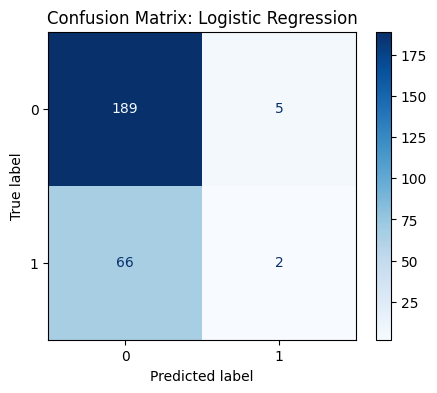

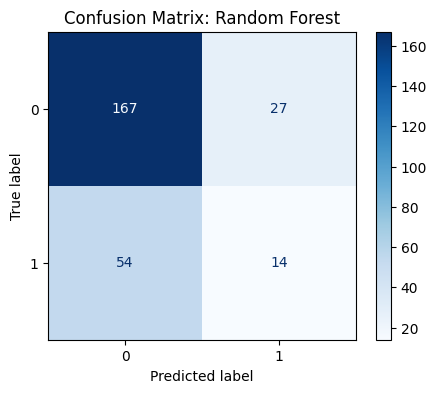

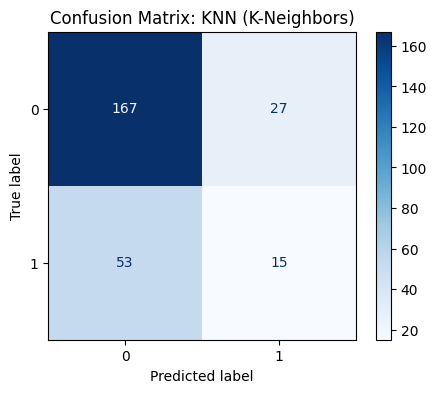


               SUMMARY PERFORMANCE TABLE               
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7290     0.2857  0.0294    0.0533
      Random Forest    0.6908     0.3415  0.2059    0.2569
  KNN (K-Neighbors)    0.6947     0.3571  0.2206    0.2727


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# 1. Initialize the 3 classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN (K-Neighbors)": KNeighborsClassifier()
}

# 2. Dictionary to store metrics for the summary table
results_data = []

# 3. Loop through each model to train, plot confusion matrix, and gather metrics
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate performance metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    # Append metrics to the results list
    results_data.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

    # Plot Confusion Matrix for each model
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=ax, cmap="Blues")
    ax.set_title(f"Confusion Matrix: {name}")
    plt.show()

# 4. Create and display the summary table
summary_df = pd.DataFrame(results_data)
print("\n" + "="*50)
print("               SUMMARY PERFORMANCE TABLE               ")
print("="*50)
print(summary_df.to_string(index=False))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6543 - loss: 0.6405 - val_accuracy: 0.7464 - val_loss: 0.5617
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7380 - loss: 0.5728 - val_accuracy: 0.7464 - val_loss: 0.5393
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7380 - loss: 0.5653 - val_accuracy: 0.7464 - val_loss: 0.5335
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7380 - loss: 0.5532 - val_accuracy: 0.7464 - val_loss: 0.5299
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7333 - loss: 0.5543 - val_accuracy: 0.7464 - val_loss: 0.5289
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7356 - loss: 0.5470 - val_accuracy: 0.7464 - val_loss: 0.5281
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7404 - loss: 0.5476 - val_accuracy: 0.7464 - val_loss: 0.5301
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7368 - loss: 0.5410 - val_accuracy: 0.7464 - val_loss: 0.5279
Ep

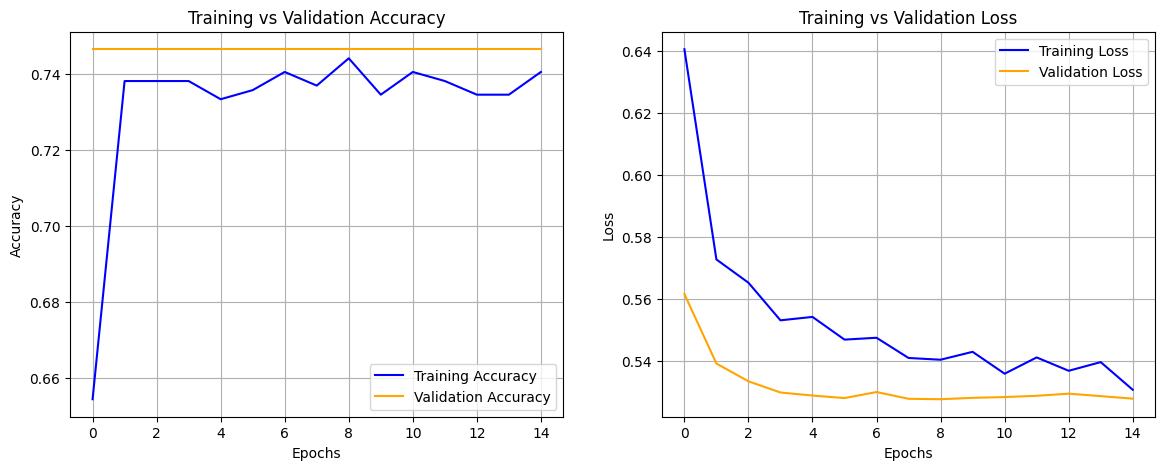

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# 1. Define the Neural Network Architecture
model_nn = Sequential([
    # Input layer + First Hidden Layer
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    # Dropout layer to reduce overfitting (as requested)
    Dropout(0.3),

    # Second Hidden Layer
    Dense(32, activation='relu',),

    # Output layer: Using Sigmoid because it's a binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

# 2. Compile the model
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model for at least 10 epochs with validation data split
# We use validation_split to track training vs validation performance
history = model_nn.fit(
    X_train, y_train,
    epochs=15,            # Meets the "at least 10 epochs" requirement
    batch_size=32,
    validation_split=0.2, # 20% of training data used for validation
    verbose=1
)

# 4. Plot the Training vs. Validation Loss and Accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy curves
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Loss curves
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Predict probabilities and convert to binary classes (0 or 1)
# Since the output layer uses sigmoid, values > 0.5 are classified as 1
nn_probs = model_nn.predict(X_test)
nn_preds = (nn_probs > 0.5).astype(int).flatten()

# 2. Calculate evaluation metrics for the Neural Network
nn_acc = accuracy_score(y_test, nn_preds)
nn_prec = precision_score(y_test, nn_preds, zero_division=0)
nn_rec = recall_score(y_test, nn_preds, zero_division=0)
nn_f1 = f1_score(y_test, nn_preds, zero_division=0)

# 3. Create a row for the Neural Network results
nn_result = {
    "Model": "Neural Network",
    "Accuracy": round(nn_acc, 4),
    "Precision": round(nn_prec, 4),
    "Recall": round(nn_rec, 4),
    "F1-Score": round(nn_f1, 4)
}

# 4. Append the Neural Network results to the existing summary table
# (Make sure 'summary_df' from Step 1 has already been created in your session)
summary_df = pd.concat([summary_df, pd.DataFrame([nn_result])], ignore_index=True)

# 5. Display the final updated summary table
print("\n" + "="*50)
print("          FINAL UPDATED SUMMARY PERFORMANCE TABLE          ")
print("="*50)
print(summary_df.to_string(index=False))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

          FINAL UPDATED SUMMARY PERFORMANCE TABLE          
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7290     0.2857  0.0294    0.0533
      Random Forest    0.6908     0.3415  0.2059    0.2569
  KNN (K-Neighbors)    0.6947     0.3571  0.2206    0.2727
     Neural Network    0.7405     0.0000  0.0000    0.0000
